<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла.

In [2]:
# Данные выгружаю из Google Drive
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DS ML Skillfactory/Python для анализа данных/dst-3.0_16_1_hh_database.csv', sep=';')
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(44744, 12)

In [3]:
print('Датафрейм состоит из:')
print('- Количество строк:', df.shape[0])
print('- Количество столбцов:', df.shape[1])

Датафрейм состоит из:
- Количество строк: 44744
- Количество столбцов: 12


2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [4]:
display(df.head())
display(df.tail())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
44739,"Мужчина , 30 лет , родился 17 января 1989",50000 руб.,"Финансист, аналитик, экономист, бухгалтер, мен...","Тверь , готов к переезду (Москва, Химки) , гот...",полная занятость,"полный день, удаленная работа","Опыт работы 7 лет 7 месяцев Финансист, аналит...","ООО ""IAS"" (независимый участник объединения Ru...",Руководитель субгруппы,Высшее образование 2015 Московский гуманитарн...,22.04.2019 12:32,Не указано
44740,"Мужчина , 27 лет , родился 5 марта 1992",39000 руб.,"Системный администратор, IT-специалист","Липецк , готов к переезду , готов к командировкам","проектная работа, частичная занятость, полная ...","удаленная работа, гибкий график, полный день, ...","Опыт работы 7 лет Системный администратор, IT...",ИП Пестрецов,Предприниматель,Высшее образование (Бакалавр) 2016 Воронежски...,22.04.2019 13:11,Не указано
44741,"Женщина , 48 лет , родилась 26 декабря 1970",40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль
44743,"Мужчина , 38 лет , родился 25 апреля 1980",120000 руб.,Руководитель проекта,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 15 лет 10 месяцев Руководитель пр...,ПАО ГК ТНС энерго,Руководитель отдела технической поддержки,Высшее образование 1997 Южно-Российский госуд...,05.07.2018 20:15,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [5]:
# Сводная информация о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

4. Обратите внимание на информацию о числе непустых значений.

In [6]:
# Информация о пустых значениях
print(f'Количество пропусков по категориям:')
display(df.isna().sum())
print(f'\nКоличество пропусков всего: {df.isna().sum().sum()}')

Количество пропусков по категориям:


,0
"Пол, возраст",0
ЗП,0
Ищет работу на должность:,0
"Город, переезд, командировки",0
Занятость,0
График,0
Опыт работы,168
Последнее/нынешнее место работы,1
Последняя/нынешняя должность,2
Образование и ВУЗ,0



Количество пропусков всего: 171


- Обнаружены неполные данные в категориях: `Опыт работы`, `Последнее/нынешнее место работы`, `Последняя/нынешняя должность`
- Количество пропусков всего: 171

5. Выведите основную статистическую информацию о столбцах.


In [7]:
df.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


- В столбце опыт работы содержится 44413 уникальных значений
- Самая распространенная должность - Системный администратор

# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [8]:
# Функция извлечения уровня образования из признака "Образование и ВУЗ"
def get_edu_level(text):
    words = text.lower().split()
    if words[0] == "высшее":
        return "высшее"
    elif words[0] == "неоконченное" and words[1] == "высшее":
        return "неоконченное высшее"
    elif words[0] == "среднее" and words[1] == "специальное":
        return "среднее специальное"
    elif words[0] == "среднее":
        return "среднее"

# Создание нового признака
df["Образование"] = df["Образование и ВУЗ"].apply(get_edu_level)

# Какие уникальные значения в новом признаке
print(f'Уникальные значения в признаке "Образование": \n{df["Образование"].unique()}')

# Количество соискателей по уровню образования
print('\nКоличество соискателей по уровню образования:')
display(df['Образование'].value_counts())

# Удаление исходного признака
df.drop('Образование и ВУЗ', axis=1, inplace=True)


Уникальные значения в признаке "Образование": 
['неоконченное высшее' 'высшее' 'среднее специальное' 'среднее']

Количество соискателей по уровню образования:


,count
Образование,
высшее,33863
среднее специальное,5765
неоконченное высшее,4557
среднее,559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина.
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '.
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [9]:
# Функция для разделения пола и возраста из признака "Пол, возраст"
def get_sex(text):
    words = text.split(',')
    sex = words[0].strip()
    sex = 'Ж' if sex == 'Женщина' else 'М'
    return sex

def get_age(text):
    words = text.split(',')
    age = words[1].split()[0].strip()
    return int(age)

# Создание новых признаков
df['Пол'] = df["Пол, возраст"].apply(get_sex)
df['Возраст'] = df["Пол, возраст"].apply(get_age)

# Удаление исходного признака
df.drop('Пол, возраст', axis=1, inplace=True)

# Проверка уникальных значений для новых признаков
print("Уникальные значения в признаке 'Пол':\n", df['Пол'].unique())

# Проверка типов данных для новых признаков
print("\nТипы данных новых признаков:\n", df[['Пол', 'Возраст']].dtypes)

# Процент женских резюме от общего количества резюие
female_ratio = (df['Пол'] == 'Ж').sum() / df.shape[0] * 100
print(f"\nПроцент женских резюме: {female_ratio:.2f} %")

# Средний возраст соискателей
mean_age = df['Возраст'].mean()  # Среднее значение по столбцу 'Возраст'
print(f"\nСредний возраст соискателей: {mean_age:.1f} лет")

Уникальные значения в признаке 'Пол':
 ['М' 'Ж']

Типы данных новых признаков:
 Пол        object
Возраст     int64
dtype: object

Процент женских резюме: 19.07 %

Средний возраст соискателей: 32.2 лет


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**.

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [10]:
# Функция для извлечения опыта работы в месяцах из признака "Опыт работы"
def get_months_experience(text):
    # Проверка на пустые значения и строку 'Не указано'
    if pd.isna(text) or text == 'Не указано':
        return np.nan

    # Ищем числа, соответствующие годам и месяцам с помощью регулярного выражения
    years = re.search(r'(\d+)\s*(год|года|лет)', text, re.IGNORECASE)
    months = re.search(r'(\d+)\s*(месяц|месяца|месяцев)', text, re.IGNORECASE)

    # Извлекаем значения с проверкой
    years_val = int(years.group(1)) if years else 0
    months_val = int(months.group(1)) if months else 0

    # Переводим всё в месяцы
    total_months = years_val * 12 + months_val
    return total_months

# Создаем новый признак "Опыт работы (месяц). Применяем функцию к столбцу "Опыт работы"
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(get_months_experience)

# Проверим соответствие старого признака с новым
print(df[['Опыт работы', 'Опыт работы (месяц)']].head(10))

# Удаление исходного признака "Опыт работы"
df.drop('Опыт работы', axis=1, inplace=True)

# Вычисляем медианный опыт работы в месяцах
# Игнорируем nan значения при расчете медианы (по умолчанию)
median_experience = df['Опыт работы (месяц)'].median(skipna=True)
print(f"\nМедианный опыт работы в месяцах: {median_experience}")

                                         Опыт работы  Опыт работы (месяц)
0  Опыт работы 16 лет 10 месяцев  Август 2010 — п...                202.0
1  Опыт работы 19 лет 5 месяцев  Январь 2000 — по...                233.0
2  Опыт работы 10 лет 3 месяца  Октябрь 2004 — Де...                123.0
3  Опыт работы 18 лет 9 месяцев  Август 2017 — Ап...                225.0
4  Опыт работы 5 лет 7 месяцев  Региональный мене...                 67.0
5  Опыт работы 9 лет 9 месяцев  Технический специ...                117.0
6  Опыт работы 22 года 9 месяцев  Руководитель ИТ...                273.0
7  Опыт работы 3 года 11 месяцев  Декабрь 2016 — ...                 47.0
8  Опыт работы 8 лет 9 месяцев  Декабрь 2016 — по...                105.0
9  Опыт работы 16 лет 6 месяцев  Июнь 2018 — по н...                198.0

Медианный опыт работы в месяцах: 100.0


In [11]:
# Выберем статистические данные признака "опыт работы"
print("\nСтатистика опыта работы:")
print(df['Опыт работы (месяц)'].describe(percentiles = [0.95, 0.99, 0.999]))

# Проверка на аномальные значения (более 50 лет опыта)
abnormal_experience = df[df['Опыт работы (месяц)'] > 50 * 12]
if not abnormal_experience.empty:
    print(f"\nОбнаружены аномальные значения опыта (>50 лет): {len(abnormal_experience)} записей")

# Количество пропущенных значений после преобразования
missing_count = df['Опыт работы (месяц)'].isna().sum()
print(f"\nПропущенных значений в новом признаке: {missing_count}")


Статистика опыта работы:
count    44574.000000
mean       127.877776
std        564.284591
min          1.000000
50%        100.000000
95%        265.000000
99%        377.000000
99.9%      518.854000
max      24230.000000
Name: Опыт работы (месяц), dtype: float64

Обнаружены аномальные значения опыта (>50 лет): 28 записей

Пропущенных значений в новом признаке: 170


- 75% имеют опыт работы до 155 месяцев
- максимальное значение **24230 месяцев** - **2019 лет** - явная аномалия!
- 99.9% кандидатов имеют опыт работы меньше **519 месяцев** - **43,3 года**

4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , …
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [12]:
# Программа для расчленения признака "Город, переезд, командировки"
def get_city_relocation_trip(text):
    million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань',
                      'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа',
                      'Красноярск', 'Пермь', 'Воронеж','Волгоград']

    words = text.split(',')
    city_name = words[0].strip()

    # Определение категории города
    if city_name == 'Москва':
        category = 'Москва'
    elif city_name == 'Санкт-Петербург':
        category = 'Санкт-Петербург'
    elif city_name in million_cities:
        category = 'город-миллионник'
    else:
        category = 'другие'

    # Готовность к переезду
    relocation = True  # по умолчанию
    for part in words[1:]:
        if 'не готов к переезду' in part or 'не готова к переезду' in part:
            relocation = False
            break

    # Готовность к командировкам
    trip = False   # по умолчанию
    for part in words[1:]:
        if 'командировкам' in part:
            if 'не готов к командировкам' not in part and 'не готова к командировкам' not in part:
                trip = True
            break

    return category, relocation, trip

# Применение функции и создание новых столбцов
df[['Город', 'Готовность к переезду', 'Готовность к командировкам']] = df['Город, переезд, командировки'].apply(lambda x: pd.Series(get_city_relocation_trip(x)))

# Вывод исходного признака и получившихся признаков
print("\nТаблица признаков до и после преобразования:")
display(df[['Город, переезд, командировки', 'Город', 'Готовность к переезду', 'Готовность к командировкам']].head())

# Проверка результатов
print("Распределение по городам:")
display(df['Город'].value_counts())
print("Соотношение по городам:")
display(df['Город'].value_counts(normalize = True))
print("\nГотовность к переезду:")
display(df['Готовность к переезду'].value_counts())
print("\nГотовность к командировкам:")
display(df['Готовность к командировкам'].value_counts())


# Расчет процента соискателей в Санкт-Петербурге
spb_percent = (df['Город'] == 'Санкт-Петербург').sum() / df.shape[0] * 100
print(f"\nПроцент кандидатов в Санкт-Петербурге: {spb_percent:.0f}%")

# Расчет процента соискателей, готовых одновременно к переездам и командировкам
count_both_true = df[(df['Готовность к переезду'] == True) & (df['Готовность к командировкам'] == True)].shape[0]
both_percent = (count_both_true / df.shape[0]) * 100
print(f"Процент кандидатов, готовых и к переезду, и к командировкам: {both_percent:.0f}%")

# Удаление исходного признака 'Город, переезд, командировки'
df.drop('Город, переезд, командировки', axis=1, inplace=True)



Таблица признаков до и после преобразования:


,"Город, переезд, командировки",Город,Готовность к переезду,Готовность к командировкам
0,"Советск (Калининградская область) , не готов к...",другие,False,False
1,"Королев , не готов к переезду , готов к редким...",другие,False,True
2,"Тверь , не готова к переезду , не готова к ком...",другие,False,False
3,"Саратов , не готов к переезду , готов к редким...",другие,False,True
4,"Москва , не готова к переезду , готова к коман...",Москва,False,True


Распределение по городам:


,count
Город,
Москва,16621
другие,15854
город-миллионник,7332
Санкт-Петербург,4937


Соотношение по городам:


...


Готовность к переезду:


,count
Готовность к переезду,
False,28719
True,16025



Готовность к командировкам:


,count
Готовность к командировкам,
True,31640
False,13104



Процент кандидатов в Санкт-Петербурге: 11%
Процент кандидатов, готовых и к переезду, и к командировкам: 32%


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [13]:
# Определение категорий занятости и графика
employment_categories = ['полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']
schedule_categories = ['полный день', 'сменный график', 'гибкий график', 'удаленная работа', 'вахтовый метод']

# Создание признаков-«мигалок» для занятости
for category in employment_categories:
    df[category] = df['Занятость'].apply(lambda x: category in str(x) if pd.notna(x) else False)

# Создание признаков-«мигалок» для графика
for category in schedule_categories:
    df[category] = df['График'].apply(lambda x: category in str(x) if pd.notna(x) else False)


# Проверка созданных признаков
print("Распределение по типам занятости:\n")
for category in employment_categories:
    count = df[category].sum()
    print(f"{category}: {count} ({count/len(df)*100:.2f}%)")

print("\nРаспределение по типам графика:\n")
for category in schedule_categories:
    count = df[category].sum()
    print(f"{category}: {count} ({count/len(df)*100:.2f}%)")

# Вывод таблиц
print("\nТаблица с первыми значениями (для проверки):")
display(df[['Занятость', 'полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']].head())
display(df[['График', 'полный день', 'сменный график', 'гибкий график', 'удаленная работа', 'вахтовый метод']].head())

# Сколько людей ищут проектную работу и волонтерство?
project_volunteering_count = df[(df['проектная работа'] == True) & (df['волонтерство'] == True)].shape[0]
print(f"\nКоличество людей, ищущих проектную работу и волонтерство: {project_volunteering_count}")

# Сколько людей хотят работать вахтовым методом и с гибким графиком?
rotation_work_flexible_count = df[(df['вахтовый метод'] == True) & (df['гибкий график'] == True)].shape[0]
print(f"\nКоличество людей, желающих работать вахтовым методом и с гибким графиком: {rotation_work_flexible_count}")

# Удаление исходных столбцов "Занятость" и "График"
df = df.drop(['Занятость', 'График'], axis=1)


Распределение по типам занятости:

полная занятость: 43284 (96.74%)
частичная занятость: 13136 (29.36%)
проектная работа: 8068 (18.03%)
волонтерство: 486 (1.09%)
стажировка: 2804 (6.27%)

Распределение по типам графика:

полный день: 41716 (93.23%)
сменный график: 12725 (28.44%)
гибкий график: 15584 (34.83%)
удаленная работа: 15022 (33.57%)
вахтовый метод: 3084 (6.89%)

Таблица с первыми значениями (для проверки):


,Занятость,полная занятость,частичная занятость,проектная работа,волонтерство,стажировка
0,"частичная занятость, проектная работа, полная ...",True,True,True,False,False
1,"частичная занятость, проектная работа, полная ...",True,True,True,False,False
2,полная занятость,True,False,False,False,False
3,"частичная занятость, проектная работа, полная ...",True,True,True,False,False
4,полная занятость,True,False,False,False,False


,График,полный день,сменный график,гибкий график,удаленная работа,вахтовый метод
0,"гибкий график, полный день, сменный график, ва...",True,True,True,True,True
1,"гибкий график, полный день, сменный график, уд...",True,True,True,True,False
2,полный день,True,False,False,False,False
3,"гибкий график, удаленная работа",False,False,True,True,False
4,полный день,True,False,False,False,False



Количество людей, ищущих проектную работу и волонтерство: 436

Количество людей, желающих работать вахтовым методом и с гибким графиком: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**.
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата,
* "proportion" - пропорция,
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования:
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [14]:
# Загружаем курсы валют
ExchangeRates = pd.read_csv('/content/drive/MyDrive/DS ML Skillfactory/Python для анализа данных/ExchangeRates.csv', sep=',')
display(ExchangeRates.head())
display(ExchangeRates.info())

# Преобразование дат к единому формату
df['update_date'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.date
ExchangeRates['date'] = pd.to_datetime(ExchangeRates['date'], format='%d/%m/%y').dt.date

# Словарь соответствия валют
currency_dict = {
    'руб.': 'RUB',
    'USD': 'USD',
    'EUR': 'EUR',
    'грн.': 'UAH',
    'бел.руб.': 'BYN',
    'KGS': 'KGS',
    'KZT': 'KZT',
    'AZN': 'AZN',
    'сум': 'UZS'
}

# Разделение столбца "ЗП" на сумму и валюту
df['salary_amount'] = df['ЗП'].str.split().str[0].astype(float)
df['salary_currency'] = df['ЗП'].str.split().str[1]

# Преобразование валюты в ISO код
df['currency_iso'] = df['salary_currency'].map(currency_dict).fillna('RUB')

# Left join с ExchangeRates по дате и валюте
df = df.merge(
    ExchangeRates[['date', 'currency', 'close', 'proportion']],
    left_on=['update_date', 'currency_iso'],
    right_on=['date', 'currency'],
    how='left'
)

# Заполнение пропусков для RUB (курс = 1, proportion = 1)
df['close'] = df['close'].fillna(1)
df['proportion'] = df['proportion'].fillna(1)

# Вычисление "ЗП (руб)"
df['ЗП (руб)'] = df['salary_amount'] * df['close'] / df['proportion']

# Вычисление медианной заработной платы в тысячах рублей, округленной до целого
median_salary = df['ЗП (руб)'].median()
median_salary_thds = round(median_salary / 1000)
print(f"Желаемая медианная заработная плата: {median_salary} рублей")
print(f"Желаемая медианная заработная плата в тысячах: {median_salary_thds} тыс. рублей")

# Удаление промежуточных столбцов
df.drop(['ЗП', 'salary_amount', 'salary_currency', 'currency_iso', 'update_date', 'date', 'currency', 'close', 'proportion'], axis=1, inplace=True)

,currency,per,date,time,close,vol,proportion
0,USD,D,29/12/17,00:00,57.6291,0,1
1,USD,D,30/12/17,00:00,57.6002,0,1
2,USD,D,31/12/17,00:00,57.6002,0,1
3,USD,D,01/01/18,00:00,57.6002,0,1
4,USD,D,02/01/18,00:00,57.6002,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5664 entries, 0 to 5663
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   currency    5664 non-null   object 
 1   per         5664 non-null   object 
 2   date        5664 non-null   object 
 3   time        5664 non-null   object 
 4   close       5664 non-null   float64
 5   vol         5664 non-null   int64  
 6   proportion  5664 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 309.9+ KB


None

Желаемая медианная заработная плата: 59019.0 рублей
Желаемая медианная заработная плата в тысячах: 59 тыс. рублей


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

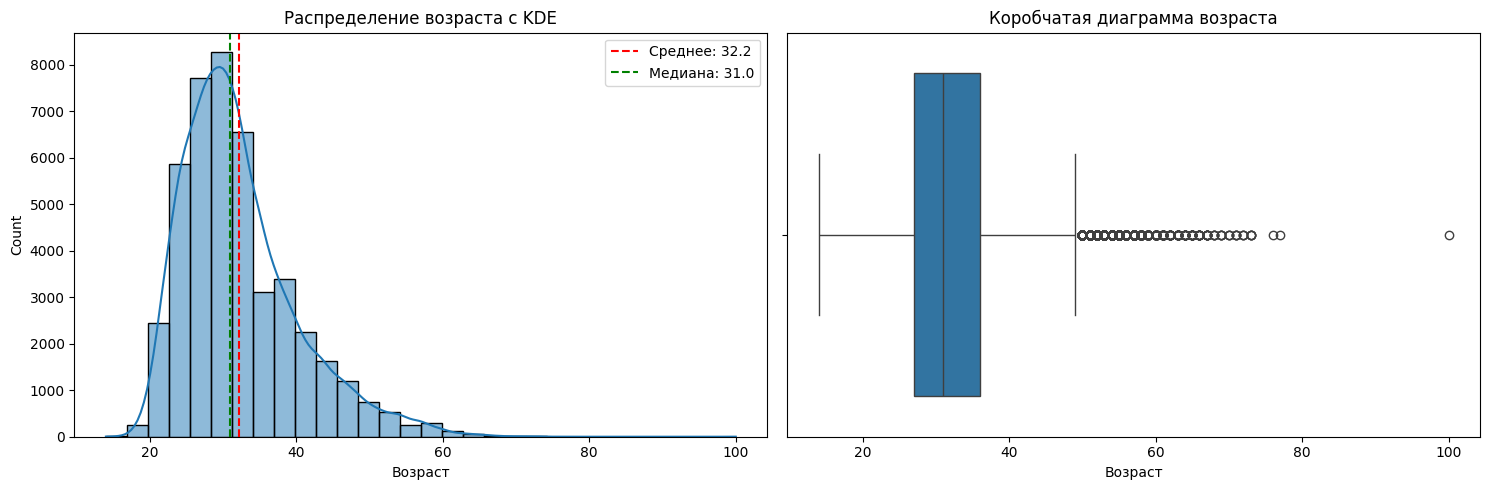

In [15]:
# Распределение признака возраст
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма с KDE
sns.histplot(data=df, x='Возраст', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение возраста с KDE')
axes[0].axvline(df['Возраст'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Возраст"].mean():.1f}')
axes[0].axvline(df['Возраст'].median(), color='green', linestyle='--', label=f'Медиана: {df["Возраст"].median():.1f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='Возраст', ax=axes[1])
axes[1].set_title('Коробчатая диаграмма возраста')

plt.tight_layout()
plt.show()

In [16]:
# Статистический анализ
print("АНАЛИЗ ВОЗРАСТОВ СОИСКАТЕЛЕЙ")

print(f"Мода распределения возраста: {df['Возраст'].mode()[0]:.2f} лет")
print(f"Средний возраст: {df['Возраст'].mean():.2f} лет")
print(f"Медианный возраст: {df['Возраст'].median():.2f} лет")


# Предельные значения
min_age = df['Возраст'].min()
max_age = df['Возраст'].max()
print(f"\nПредельные значения:")
print(f"Минимальный возраст: {min_age} лет")
print(f"Максимальный возраст: {max_age} лет")
print(f"Размах: {max_age - min_age} лет")

# Интервал возрастов большинства соискателей
q1 = df['Возраст'].quantile(0.25)
q3 = df['Возраст'].quantile(0.75)
print(f"Возраст большинства соискателей: от {int(q1)} до {int(q3)} лет")

# Анализ аномалий
print("\nАНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ")

'''
К аномалиям по возрасту я бы причислил людей до 16 лет и людей после 70 лет.
Вряд ли люди в таком возрасте являются соискателями вакансий (для анализа принимаю этот вариант)

С другой стороны каждый случай уникален и рассматривается отдельно.
'''
age_threshold_low = 16
age_threshold_high = 70

anomalies_low = df[df['Возраст'] < age_threshold_low]
anomalies_high = df[df['Возраст'] > age_threshold_high]

print(f"\nАномалии по фиксированным границам (меньше {age_threshold_low} лет и больше {age_threshold_high} лет):")
print(f"\nВозраст меньше {age_threshold_low} лет: {len(anomalies_low)} записей")
display(anomalies_low[['Возраст']].value_counts())

print(f"\nВозраст больше {age_threshold_high} лет: {len(anomalies_high)} записей")
display(anomalies_high[['Возраст']].value_counts())

АНАЛИЗ ВОЗРАСТОВ СОИСКАТЕЛЕЙ
Мода распределения возраста: 30.00 лет
Средний возраст: 32.20 лет
Медианный возраст: 31.00 лет

Предельные значения:
Минимальный возраст: 14 лет
Максимальный возраст: 100 лет
Размах: 86 лет
Возраст большинства соискателей: от 27 до 36 лет

АНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ

Аномалии по фиксированным границам (меньше 16 лет и больше 70 лет):

Возраст меньше 16 лет: 3 записей


,count
Возраст,
15,2
14,1



Возраст больше 70 лет: 14 записей


,count
Возраст,
71,4
73,4
72,3
76,1
77,1
100,1


- Мода распределения возраста: 30.00 лет (Средний возраст: 32.20 лет, Медианный возраст: 31.00 лет)
- Гистограмма распределения смещена влево из-за аномально больших значений справа
- Возраст большинства соискателей: от 27 до 36 лет, суля по межквартильному размаху
- За аномальный возраст я считаю соискателей до 16 лет и старше 70 лет. Нашлось 17 человек

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [17]:
# Замечаем большое количество опыта работы больше 20к, что нереально. Удалим их из дф методом фильтрации

print('ОЧЕНЬ СИЛЬНО АНОМАЛЬНЫЙ ОПЫТ РАБОТЫ:')
experience_over20000 = df[df['Опыт работы (месяц)'] >20000]
display(experience_over20000['Опыт работы (месяц)'].value_counts())

# Создадим копию дф и отфильтруем
df_copy = df.copy()
df = df[df['Опыт работы (месяц)'] < 20000]

#Подсчитаем количество удаленных строк
print(f'\nУдалено строк после фильтрациии: {df_copy.shape[0]-df.shape[0]}')

ОЧЕНЬ СИЛЬНО АНОМАЛЬНЫЙ ОПЫТ РАБОТЫ:


,count
Опыт работы (месяц),
24220.0,4
24213.0,3
24225.0,2
24215.0,1
24230.0,1
24202.0,1
24224.0,1
24174.0,1
24196.0,1



Удалено строк после фильтрациии: 194


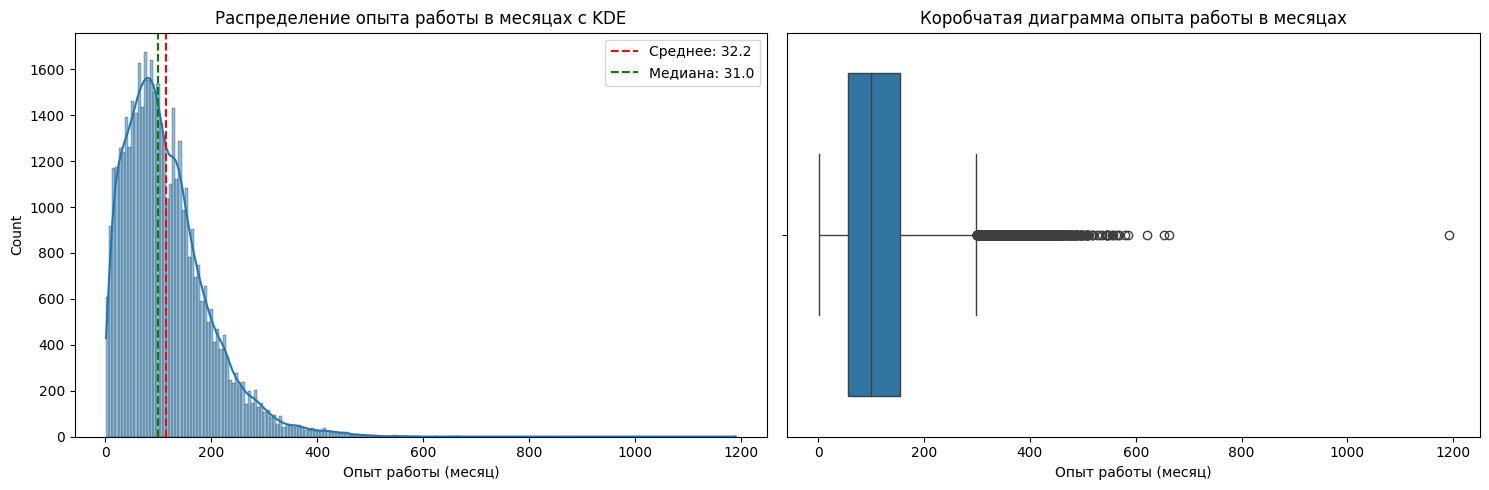

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма с KDE
sns.histplot(data=df, x='Опыт работы (месяц)', bins=200, kde=True, ax=axes[0])
axes[0].set_title('Распределение опыта работы в месяцах с KDE')
axes[0].axvline(df['Опыт работы (месяц)'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Возраст"].mean():.1f}')
axes[0].axvline(df['Опыт работы (месяц)'].median(), color='green', linestyle='--', label=f'Медиана: {df["Возраст"].median():.1f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='Опыт работы (месяц)', ax=axes[1])
axes[1].set_title('Коробчатая диаграмма опыта работы в месяцах')

plt.tight_layout()
plt.show()

In [19]:
# Статистический анализ
print("АНАЛИЗ ОПЫТА РАБОТЫ (В МЕСЯЦАХ) СОИСКАТЕЛЕЙ")

print(f"Мода распределения опыта: {df['Опыт работы (месяц)'].mode()[0]:.2f} мес")
print(f"Средний опыт работы (месяц): {df['Опыт работы (месяц)'].mean():.2f} мес")
print(f"Медианный Опыт работы (месяц): {df['Опыт работы (месяц)'].median():.2f} мес")


# Предельные значения
min_exp = df['Опыт работы (месяц)'].min()
max_exp = df['Опыт работы (месяц)'].max()
print(f"\nПредельные значения:")
print(f"Минимальный возраст: {min_exp} мес")
print(f"Максимальный возраст: {max_exp} мес")
print(f"Размах: {max_exp - min_exp} мес")

# Интервал возрастов большинства соискателей
q1 = df['Опыт работы (месяц)'].quantile(0.25)
q3 = df['Опыт работы (месяц)'].quantile(0.75)
print(f"Опыт работы большинства соискателей: от {int(q1)} до {int(q3)} мес")

# Анализ аномалий
print("\nАНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ")

'''
Считаю опыт работы больше 55 лет аномальным... это 660 месяцев
'''
exp_threshold = 660

anomalies_high = df[df['Опыт работы (месяц)'] > exp_threshold]

print(f"\nАномалии по фиксированным границам больше {exp_threshold} мес:")

print(f"\nОпыт работы больше {exp_threshold} мес ({exp_threshold/12} лет): {len(anomalies_high)} записей")
display(anomalies_high[['Опыт работы (месяц)']].value_counts())

АНАЛИЗ ОПЫТА РАБОТЫ (В МЕСЯЦАХ) СОИСКАТЕЛЕЙ
Мода распределения опыта: 81.00 мес
Средний опыт работы (месяц): 114.91 мес
Медианный Опыт работы (месяц): 100.00 мес

Предельные значения:
Минимальный возраст: 1.0 мес
Максимальный возраст: 1191.0 мес
Размах: 1190.0 мес
Опыт работы большинства соискателей: от 57 до 154 мес

АНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ

Аномалии по фиксированным границам больше 660 мес:

Опыт работы больше 660 мес (55.0 лет): 2 записей


,count
Опыт работы (месяц),
663.0,1
1191.0,1


- Мода распределения опыта работы равна 81.0 месяцам (около 7 лет).
- Предельные значения признака? Предельные значения признака "Опыт работы (месяц)" — от 1.0 месяца (минимальное значение) до 1191.0 месяцев (максимальное значение).
- Опыт работы большинства соискателей от 57.0 до 154.0 месяцев (от 5 до 13 лет).
- Распределение тяготеет к левому краю (относительно молодые специалисты).
- Аномалии присутствуют. Помимо удаления опыта больее 20000 месяцев, в данных остались предельные значения.
- К аномалиям я причислил опыт в 55 лет (660 месяцев). В анализе нашлось только два кандидата превышающих придуманную мной цифру - 663 и 1191. Причем 663 близко к моим границам. Таким образовм в отфильтрованном датасете только одно аномальное значения по опыту работы - это 1191 месяц (или почти 100 лет).


3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


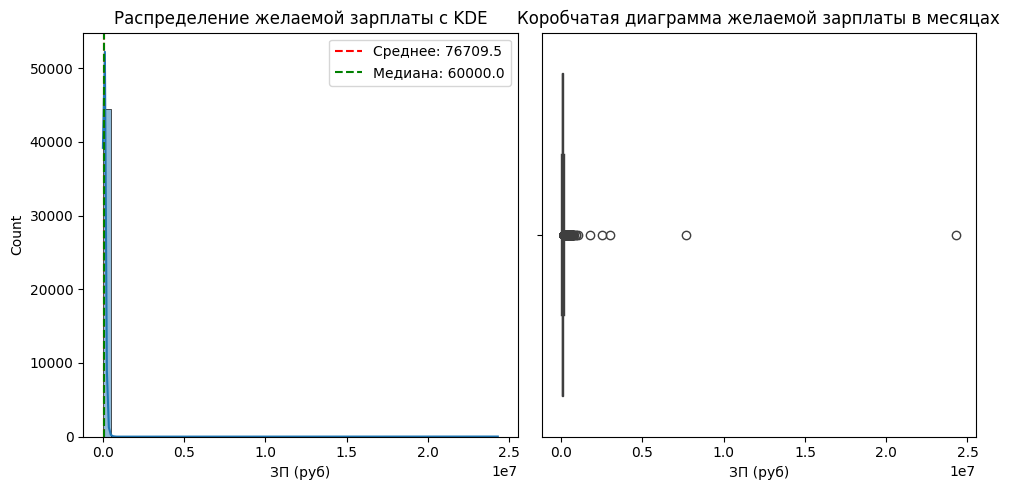

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Гистограмма с KDE
sns.histplot(data=df, x='ЗП (руб)', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Распределение желаемой зарплаты с KDE')
axes[0].axvline(df['ЗП (руб)'].mean(), color='red', linestyle='--', label=f'Среднее: {df["ЗП (руб)"].mean():.1f}')
axes[0].axvline(df['ЗП (руб)'].median(), color='green', linestyle='--', label=f'Медиана: {df["ЗП (руб)"].median():.1f}')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='ЗП (руб)', ax=axes[1])
axes[1].set_title('Коробчатая диаграмма желаемой зарплаты в месяцах')

plt.tight_layout()
plt.show()

In [21]:
# Статистический анализ
print("АНАЛИЗ ЖЕЛАЕМОЙ ЗАРПЛАТЫ СОИСКАТЕЛЕЙ")

print(f"Мода распределения: {df['ЗП (руб)'].mode()[0]:.2f} руб")
print(f"Средняя ЗП: {df['ЗП (руб)'].mean():.2f} руб")
print(f"Медианная ЗП: {df['ЗП (руб)'].median():.2f} руб")


# Предельные значения
min_sal = df['ЗП (руб)'].min()
max_sal = df['ЗП (руб)'].max()
print(f"\nПредельные значения:")
print(f"Минимальая желаемая ЗП: {min_sal} руб")
print(f"Максимальный желаемая ЗП:: {max_sal} руб")

# Интервал возрастов большинства соискателей
q1 = df['ЗП (руб)'].quantile(0.25)
q3 = df['ЗП (руб)'].quantile(0.75)
print(f"Диапазон ожидаемой ЗП: от {int(q1)} до {int(q3)} руб")

# Анализ аномалий
print("\nАНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ")

'''
Аномалии - это отрицательная зп, зп ниже прожиточного минимума
(пусть 18000 рублей) и зп, скажем, больше 3 млн. рублей.
Как мне кажется, что свердоходные вакансии не ищутся на сайтах вакакнсий
'''
sal_threshold_low = 18000
sal_threshold_high = 3000000

anomalies_low = df[df['ЗП (руб)'] < sal_threshold_low]
anomalies_high = df[df['ЗП (руб)'] > sal_threshold_high]

print(f"\nАномалии по фиксированным границам (меньше {sal_threshold_low} и больше {sal_threshold_high} рублей):")
print(f"\nЗП меньше {sal_threshold_low} рублей: {len(anomalies_low)} записей")
display(anomalies_low[['ЗП (руб)']].value_counts())

print(f"\nЗП больше {sal_threshold_high} рублей: {len(anomalies_high)} записей")
display(anomalies_high[['ЗП (руб)']].value_counts())

# Подсчитываем количество соискателей с зарплатой выше 1 миллиона рублей
count_high_salary = (df['ЗП (руб)'] > 1000000).sum()
print(f"Количество соискателей с зарплатой выше 1 миллиона рублей: {count_high_salary}")


АНАЛИЗ ЖЕЛАЕМОЙ ЗАРПЛАТЫ СОИСКАТЕЛЕЙ
Мода распределения: 50000.00 руб
Средняя ЗП: 76709.53 руб
Медианная ЗП: 60000.00 руб

Предельные значения:
Минимальая желаемая ЗП: 1.0 руб
Максимальный желаемая ЗП:: 24304876.0 руб
Диапазон ожидаемой ЗП: от 38376 до 95000 руб

АНАЛИЗ АНОМАЛЬНЫХ ЗНАЧЕНИЙ

Аномалии по фиксированным границам (меньше 18000 и больше 3000000 рублей):

ЗП меньше 18000 рублей: 1022 записей


,count
ЗП (руб),
15000.00,331
10000.00,180
16868.00,46
17015.10,33
16879.90,30
...,...
15792.53,1
16847.60,1
17166.60,1



ЗП больше 3000000 рублей: 2 записей


,count
ЗП (руб),
7675224.0,1
24304876.0,1


Количество соискателей с зарплатой выше 1 миллиона рублей: 5


- По гистограмме сразу видно, что с ней что-то не так
- Ящик с усам показал очень высокую желаемую зарплату, что повлияло на визуальное восприятие графиков
- В основном диапазон желаемой заработной платы от 35 тыс. рублей до 95 тыс. рублей.
- За аномалии считаю желаемую ЗП ниже прожиточного минимума (в анализе 18 тыс. рублей) - выявлено около 1000 соискателей. И выше 3 миллионов. Высокодоходные вакансии вряд ли выложены в сети. Выявлено 2 аномалии

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

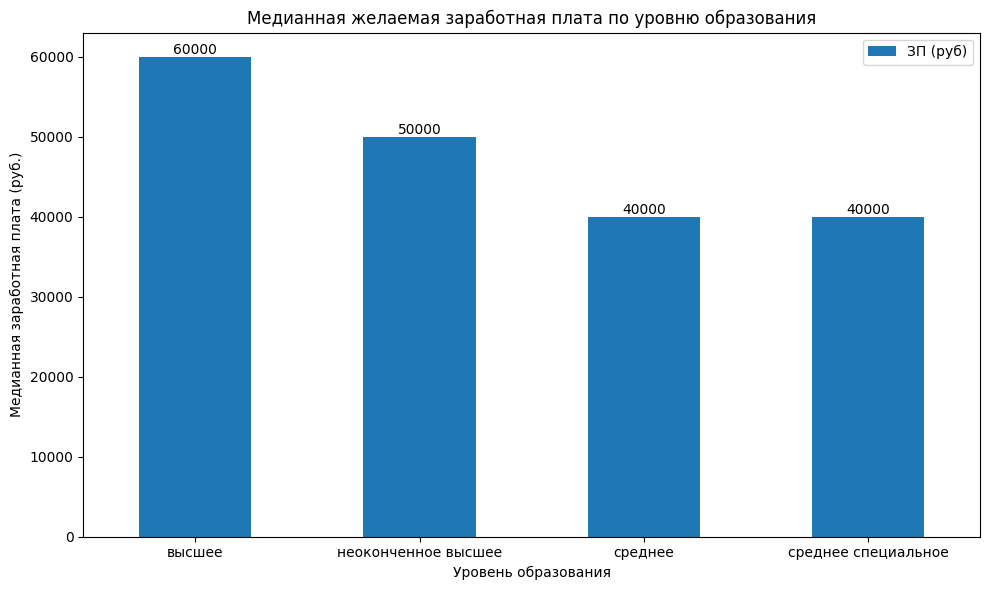

In [22]:
# Отфильтруем данные по условию ЗП менее 1 млн рублей
df_filtered = df[df['ЗП (руб)'] < 1_000_000]

# Сгруппируем данные по уровню образования и вычислим медианную заработную плату
median_salary_by_grade = df_filtered.groupby('Образование', as_index=False)['ЗП (руб)'].median()

# Построим столбчатую диаграмму
ax = median_salary_by_grade.plot(
    kind='bar',
    x='Образование',
    y='ЗП (руб)',
    figsize=(10, 6),
)
# Настроим подписи и заголовок
ax.set_title('Медианная желаемая заработная плата по уровню образования')
ax.set_xlabel('Уровень образования')
ax.set_ylabel('Медианная заработная плата (руб.)')

# Настроим подписи (уровни образования)
ax.set_xticklabels(median_salary_by_grade['Образование'],rotation=0,fontsize=10)
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

- Ожидаемый уровень ЗП наибольший у соискателей с высшим образованием. Что логично
- Наименьший у соисктелей со средним и среднеспециальным образованием
- Признак уровня образования важен при прогнозировании заработной платы. Диаграмма демонстрирует четкую положительную зависимость: выше уровень - выше ожидания

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

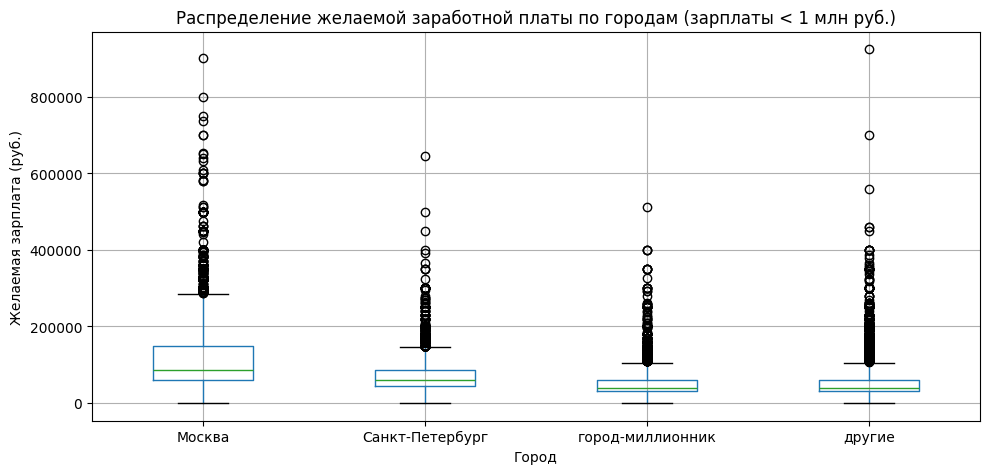

In [23]:
df_filtered.boxplot(
    column='ЗП (руб)',
    by='Город',
    figsize=(10, 5),
    rot=0,
)

# Настраиваем заголовок и подписи
plt.suptitle('')
plt.title('Распределение желаемой заработной платы по городам (зарплаты < 1 млн руб.)')
plt.xlabel('Город')
plt.ylabel('Желаемая зарплата (руб.)')


plt.tight_layout()
plt.show()

- Чем крупнее город,тем выше медианный уровень по желаемой заработной плате
- Тоже и для межквартильного размаха. Больше город - шире диапазон по желаемым зарплатам
- Диаграмма показывает значительные различия в медианах и размахе, связанные с населением в городе. Признак города важен при прогнозировании заработной платы.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

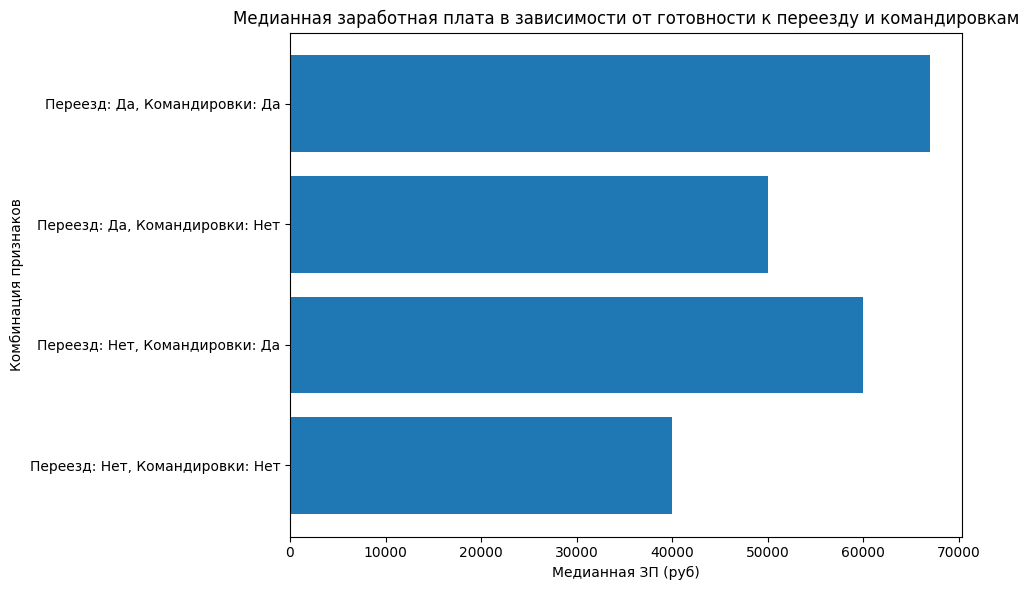

Желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам в тысячах рублей: 67


In [24]:
# Группировка по признакам и расчет медианной ЗП
grouped = df.groupby(['Готовность к переезду', 'Готовность к командировкам'], as_index=False)['ЗП (руб)'].median()

# Создание нового столбца с комбинированными метками для осей
grouped['Комбинация'] = grouped.apply(
    lambda row: f"Переезд: {'Да' if row['Готовность к переезду'] else 'Нет'}, Командировки: {'Да' if row['Готовность к командировкам'] else 'Нет'}",
    axis=1
)

# Построение столбчатой диаграммы по комбинациям
plt.figure(figsize=(10, 6))
bars = plt.barh(grouped['Комбинация'], grouped['ЗП (руб)'])
plt.title('Медианная заработная плата в зависимости от готовности к переезду и командировкам')
plt.ylabel('Комбинация признаков')
plt.xlabel('Медианная ЗП (руб)')

plt.tight_layout()
plt.show()

# Расчет медианной ЗП для соискателей, готовых и к переезду, и к командировкам
median_sal = grouped[(grouped['Готовность к переезду'] == True) & (grouped['Готовность к командировкам'] == True)]['ЗП (руб)'].values[0]
print(f"Желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам в тысячах рублей: {round(median_sal/1000)}")


- Самая высокая ЗП наблюдается в категории "Да переезд, Да командировки" (такие соискатели наиболее привлекательны для работодателей)
- Готовность только к командировкам дает более высокую ЗП, чем готовность только к переезду
- Низкий уровень зп у так называемых "негибких" соискателей.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

In [25]:
# Построение сводной таблицы: медианная желаемая зарплата (ЗП (руб)) по возрасту (индекс) и образованию (столбцы)
pivot_table = df.pivot_table(values='ЗП (руб)', index='Возраст', columns='Образование', aggfunc='median')

# Построение тепловой карты с помощью plotly
fig = px.imshow(pivot_table,
                aspect="auto",
                text_auto=False,
                title="Тепловая карта медианной желаемой заработной платы по возрасту и образованию")
fig.show()

- Зарплаты растут с опытом для всех уровней образования. Однако темп роста разный. Бстреевсех рост у соискателей с высшим образованием, медленее -у среднего и среднеспециального.
- Уровень ЗП на старте карьеры визуально одинаков.


8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

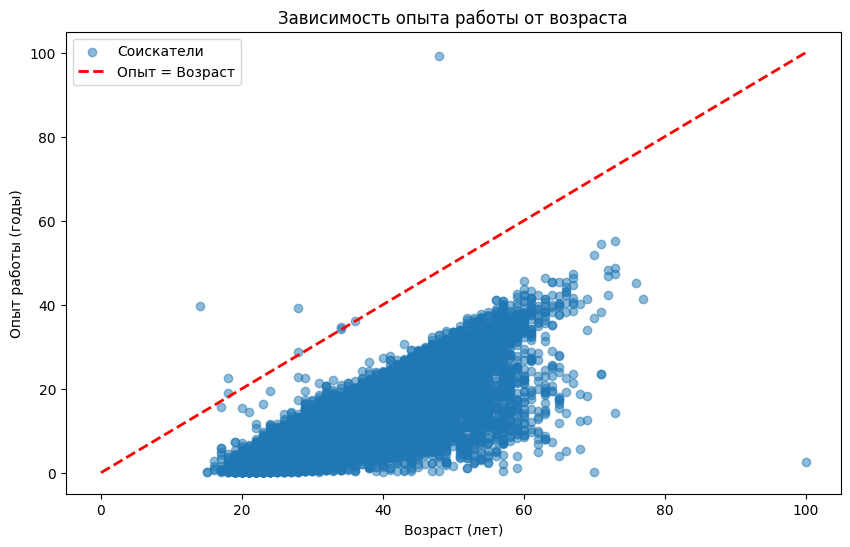

In [26]:
# Переводим опыт работы из месяцев в года
df['Опыт_года'] = df['Опыт работы (месяц)'] / 12

# Строим диаграмму рассеяния
plt.figure(figsize=(10, 6))
plt.scatter(df['Возраст'], df['Опыт_года'], alpha=0.5, label='Соискатели')

# Строим прямую через точки (0, 0) и (100, 100)
plt.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=2, label='Опыт = Возраст')

# Добавляем подписи осей и заголовок
plt.xlabel('Возраст (лет)')
plt.ylabel('Опыт работы (годы)')
plt.title('Зависимость опыта работы от возраста')
plt.legend()


plt.show()

- С увеличением возраста опыт работы соискателей в растет
- Большинство точек находятся ниже красной пунктирной линии, что соответствует норме (опыт меньше возраста). Однако видны аномалии — точки на линии или выше нее, где опыт работы превышает или равен возрасту


**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


ваши выводы здесь

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их.

In [27]:
'''
Так как я фильтровал дф из-за аномалий в в опыте работы (24000 месяцев), а задание требует
анализа исходного ДФ, то я воспользуюсь для дальнейего анализа копией ДФ до фильтрации
'df_copy'
'''
# Полные дубликаты
duplicates = df_copy[df_copy.duplicated()]

# Выведем количество полных дубликатов
num_duplicates = len(duplicates)
print(f"Количество полных дубликатов: {num_duplicates}")

Количество полных дубликатов: 158


In [28]:
# Удалим полные дубликаты (оставим первое вхождение каждой уникальной строки)
df_copy = df_copy.drop_duplicates()

# Выведем размер DataFrame после удаления
print(f"Размер ДФ после удаления дубликатов: {df.shape}")

Размер ДФ после удаления дубликатов: (44550, 24)


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах.

In [29]:
# Выведем число пропусков в каждом столбце
print("Число пропусков в столбцах:")
df_copy.isna().sum()

print(f'Число пропусков в категории "Опыт работы" - {df_copy['Опыт работы (месяц)'].isna().sum()}')


Число пропусков в столбцах:
Число пропусков в категории "Опыт работы" - 168


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [30]:
# Удалим строки с пропусками в "Последнее/нынешнее место работы" или "Последняя/нынешняя должность"
df_clean = df_copy.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность']).copy()
df_clean = df_clean[df_clean['Опыт работы (месяц)'] < 20000] #удалим аномалии

# Вычислим медиану по столбцу "Опыт работы (месяц)"
median_exp = df_clean['Опыт работы (месяц)'].median()

# Заполним пропуски в "Опыт работы (месяц)" медианным значением
df_clean['Опыт работы (месяц)'] = df_clean['Опыт работы (месяц)'].fillna(median_exp)

# Вычислим среднее значение в столбце "Опыт работы (месяц)" после заполнения
mean_exp = df_clean['Опыт работы (месяц)'].mean()

# Вывести результат
print('результирующее среднее значение в столбце «Опыт работы (месяц)» после заполнения пропусков')
print(f'{mean_exp:.0f}')

результирующее среднее значение в столбце «Опыт работы (месяц)» после заполнения пропусков
115


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [31]:
# Удалим резюме, где заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей
df_filtered = df_clean[(df_clean['ЗП (руб)'] >= 1000) & (df_clean['ЗП (руб)'] <= 1000000)].copy()

# Количество выбросов
outliers_count = len(df_clean) - len(df_filtered)
print(f"Количество выбросов: {outliers_count}")

Количество выбросов: 87


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [32]:
df_filtered['Опыт_года'] = df_filtered['Опыт работы (месяц)'] / 12
df_final = df_filtered[df_filtered['Опыт_года'] < df_filtered['Возраст']].copy()

# Определить количество выбросов (резюме, где опыт в годах превышает возраст)
outliers_count_exp_age = len(df_filtered) - len(df_final)

# Вывести количество выбросов
print(f"Количество выбросов: {outliers_count_exp_age}")

Количество выбросов: 9


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

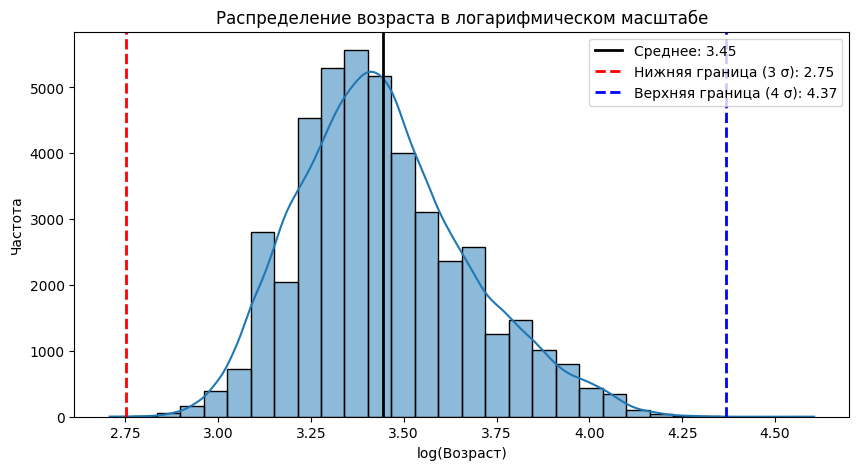

In [33]:
# Создаем логарифм возраста
df_final['log_age'] = np.log(df_final['Возраст'])

# Строим распределение в логарифмическом масштабе
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_final['log_age'], ax=ax, bins=30, kde=True)
ax.set_title('Распределение возраста в логарифмическом масштабе')
ax.set_xlabel('log(Возраст)')
ax.set_ylabel('Частота')

# Среднее и стандартное отклонение для log_age
mean_log_age = df_final['log_age'].mean()
std_log_age = df_final['log_age'].std()

# Границы интервала: нижняя - mean - 3*std, верхняя - mean + 4*std
lower_bound = mean_log_age - 3 * std_log_age
upper_bound = mean_log_age + 4 * std_log_age #послабление

# Добавим линии: среднее, нижняя и верхняя границы
ax.axvline(mean_log_age, color='k', lw=2, label=f'Среднее: {mean_log_age:.2f}')
ax.axvline(lower_bound, color='r', lw=2, linestyle='--', label=f'Нижняя граница (3 σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='b', lw=2, linestyle='--', label=f'Верхняя граница (4 σ): {upper_bound:.2f}')

# Легенда
ax.legend()

plt.show()


In [34]:
# Выбросы с помощью z-отклонения (нижняя: z < -3, верхняя: z > 4)
z_scores = (df_final['log_age'] - mean_log_age) / std_log_age
outliers_mask = (z_scores < -3) | (z_scores > 4)
df_outliers = df_final[outliers_mask].copy()

# Таблица с выбросами
print("Резюме с возрастом, попадающим под выбросы по методу z-отклонения:")
display(df_outliers[['Возраст', 'log_age']])

# Оценка возраста соискателей, попадающих под категорию выбросов
min_outlier_age = np.exp(lower_bound)
max_outlier_age = np.exp(upper_bound)
print(f"\nОценка: Соискатели с возрастом ниже {min_outlier_age:.1f} лет или выше {max_outlier_age:.1f} лет попадают под категорию выбросов.")
print(f"Количество выбросов: {len(df_outliers)}")

# Удалим выбросы из данных (создать новый DataFrame)
df_final_no_outliers = df_final[~outliers_mask].copy()

Резюме с возрастом, попадающим под выбросы по методу z-отклонения:


,Возраст,log_age
31137,15,2.70805
32950,15,2.70805
33654,100,4.60517



Оценка: Соискатели с возрастом ниже 15.7 лет или выше 78.8 лет попадают под категорию выбросов.
Количество выбросов: 3
